# Group 60 — Sentiment Analysis in African Languages
## AfriSenti | NLP Project Notebook
**Members:** Praises Obi (u26819661) · Bob Dlamini (u21739120) · Ishe Allen Chihobo (u22592238)

---
| Phase | Dates | Content |
|---|---|---|
| 1 | 5–19 Apr | Setup · Data · EDA · TF-IDF Baseline · Code-Mixing Filter |
| 2 | 20 Apr–3 May | LAFT: Monolingual AfroXLMR Fine-Tuning |
| 3 | 4–10 May | mBERT Fine-Tuning · MAFT: Multilingual AfroXLMR |
| 4 | 11-14 May | Code-mixing diagnostic, LIME error analysis, taxonomy


---
# Phase 1 — Setup, Data, EDA, TF-IDF Baseline

In [15]:
# Install all dependencies
!pip install -q transformers datasets scikit-learn langdetect matplotlib seaborn accelerate


In [16]:
import os
import json
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, set_seed,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from langdetect import detect_langs

print("✅ All imports done.")


✅ All imports done.


In [17]:
# ── Kaggle-native paths (replaces Google Drive mount) ─────────────
# attached dataset
INPUT_DIR = Path(
    "/kaggle/input/datasets/praisesobi/group60-nlp/group60_nlp-20260521T223451Z-3-002/group60_nlp-20260521T223451Z-3-002/group60_nlp")
SAVE_DIR = Path('/kaggle/working')             # writable output dir
SAVE_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_FILE = INPUT_DIR / 'all_results.json'      # loaded from dataset input


def load_results():
    """Load cached results from the attached Kaggle dataset."""
    if RESULTS_FILE.exists():
        print(f"  Found all_results.json in {INPUT_DIR}")
        return json.loads(RESULTS_FILE.read_text())
    print("  ⚠️  all_results.json not found in dataset — starting fresh.")
    return {}


def save_results(results: dict):
    """Save results to /kaggle/working (download after session)."""
    out = SAVE_DIR / 'all_results.json'
    out.write_text(json.dumps(results, indent=2))
    print(f"  Saved → {out}")


# Also check what files are available in the dataset
print(f"✅ Kaggle paths configured.")
print(f"   Input  : {INPUT_DIR}")
print(f"   Output : {SAVE_DIR}")
if INPUT_DIR.exists():
    files = list(INPUT_DIR.iterdir())
    print(f"   Files in dataset ({len(files)}):")
    for f in sorted(files)[:20]:
        print(f"     {f.name}")
else:
    print("   ⚠️  Input dataset not found — check it is attached in the Input panel.")


✅ Kaggle paths configured.
   Input  : /kaggle/input/datasets/praisesobi/group60-nlp/group60_nlp-20260521T223451Z-3-002/group60_nlp-20260521T223451Z-3-002/group60_nlp
   Output : /kaggle/working
   Files in dataset (16):
     all_results.json
     ckpt_laft_ibo_seed123
     ckpt_laft_yor_seed456
     ckpt_mbert_pcm_seed42
     ckpt_mbert_pcm_seed456
     ckpt_mbert_swa_seed42
     cm_laft_hau_seed123.png
     cm_laft_hau_seed456.png
     cm_laft_ibo_seed123.png
     cm_laft_pcm_seed456.png
     cm_laft_swa_seed123.png
     cm_laft_swa_seed42.png
     cm_laft_yor_seed42.png
     cm_laft_yor_seed456.png
     dataset_stats.csv
     tweet_lengths.png


In [18]:
# Global config
SEEDS = [42, 123, 456]
LABEL2ID = {'positive': 0, 'negative': 1, 'neutral': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

LANGUAGES = {
    'hau': {'name': 'Hausa',           'family': 'Afro-Asiatic',   'region': 'West Africa'},
    'yor': {'name': 'Yoruba',          'family': 'Niger-Congo',    'region': 'West Africa'},
    'ibo': {'name': 'Igbo',            'family': 'Niger-Congo',    'region': 'West Africa'},
    'pcm': {'name': 'Nigerian Pidgin', 'family': 'English Creole', 'region': 'West Africa'},
    'swa': {'name': 'Swahili',         'family': 'Niger-Congo',    'region': 'East Africa'},
}


def set_all_seeds(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    set_seed(seed)


print("✅ Config set.")


✅ Config set.


## 1.1 Data Download

In [19]:
base = "https://raw.githubusercontent.com/afrisenti-semeval/afrisent-semeval-2023/main/data/{lang}/{split}.tsv"


def download_split(lang_iso: str, split: str) -> pd.DataFrame:
    url = base.format(lang=lang_iso, split=split)
    df = pd.read_csv(url, sep='\t', header=None, names=['tweet', 'label'],
                     on_bad_lines='skip')
    df = df.dropna(subset=['tweet', 'label'])
    df['label'] = df['label'].str.strip().str.lower()
    df = df[df['label'].isin(LABEL2ID)].copy()
    df['label_id'] = df['label'].map(LABEL2ID)
    df['iso'] = lang_iso
    return df.reset_index(drop=True)


def load_language(iso: str) -> dict:
    print(f"  Downloading {LANGUAGES[iso]['name']}...")
    data = {
        'train': download_split(iso, 'train'),
        'val':   download_split(iso, 'dev'),
        'test':  download_split(iso, 'test'),
    }
    for split, df in data.items():
        print(f"    {split}: {len(df)}")
    return data


all_data = {}
for iso in LANGUAGES:
    all_data[iso] = load_language(iso)

print("\n✅ All 5 languages downloaded.")


    train: 14172
    val: 2677
    test: 5303
    train: 8522
    val: 2090
    test: 4515
    train: 10192
    val: 1841
    test: 3682
    train: 5121
    val: 1281
    test: 4154
    train: 1810
    val: 453
    test: 748

✅ All 5 languages downloaded.


## 1.2 EDA — Dataset Statistics

In [20]:
rows = []
for iso, cfg in LANGUAGES.items():
    for split in ['train', 'val', 'test']:
        df = all_data[iso][split]
        counts = df['label'].value_counts()
        rows.append({
            'Language': cfg['name'], 'Split': split, 'Total': len(df),
            'Positive': counts.get('positive', 0),
            'Negative': counts.get('negative', 0),
            'Neutral':  counts.get('neutral',  0),
        })

stats_df = pd.DataFrame(rows)
stats_df.to_csv(SAVE_DIR / 'dataset_stats.csv', index=False)
print(stats_df.to_string(index=False))


       Language Split  Total  Positive  Negative  Neutral
          Hausa train  14172      4687      4573     4912
          Hausa   val   2677       887       894      896
          Hausa  test   5303      1755      1759     1789
         Yoruba train   8522      3542      1872     3108
         Yoruba   val   2090       884       443      763
         Yoruba  test   4515      1918       981     1616
           Igbo train  10192      3084      2600     4508
           Igbo   val   1841       560       470      811
           Igbo  test   3682      1118       943     1621
Nigerian Pidgin train   5121      1808      3241       72
Nigerian Pidgin   val   1281       447       813       21
Nigerian Pidgin  test   4154      1397      2326      431
        Swahili train   1810       547       191     1072
        Swahili   val    453       137        48      268
        Swahili  test    748       224        80      444


## 1.3 EDA — Label Distribution Plot

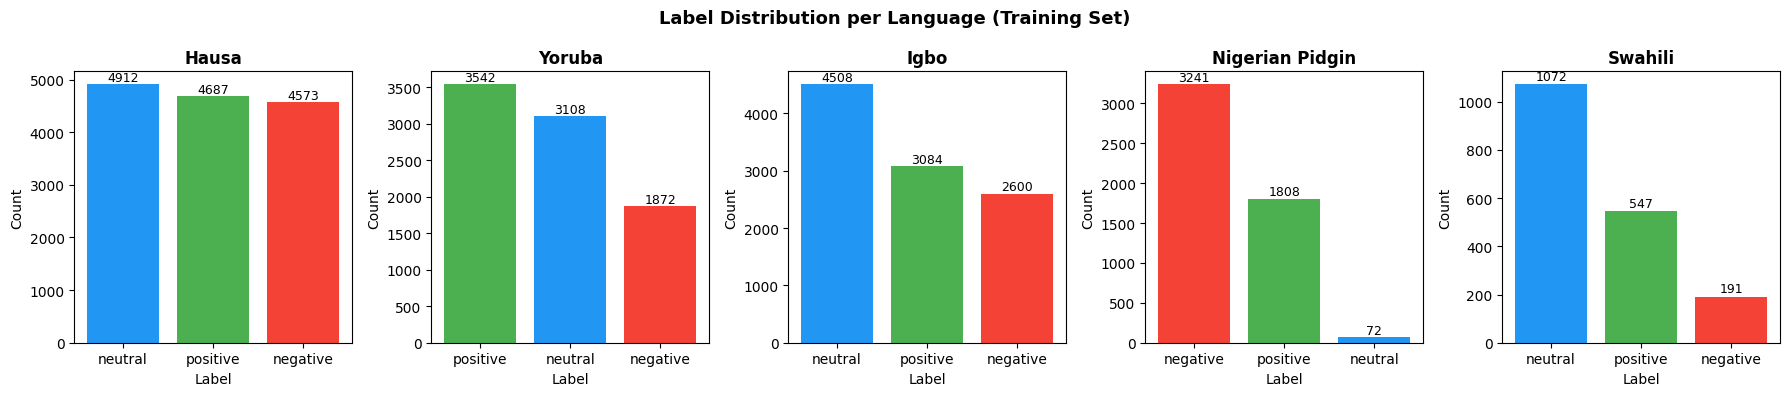

In [21]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Label Distribution per Language (Training Set)', fontsize=13, fontweight='bold')
colors = {'positive': '#4CAF50', 'negative': '#F44336', 'neutral': '#2196F3'}

for ax, (iso, cfg) in zip(axes, LANGUAGES.items()):
    counts = all_data[iso]['train']['label'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=[colors[l] for l in counts.index])
    ax.set_title(cfg['name'], fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xlabel('Label')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.4 EDA — Tweet Length Distribution

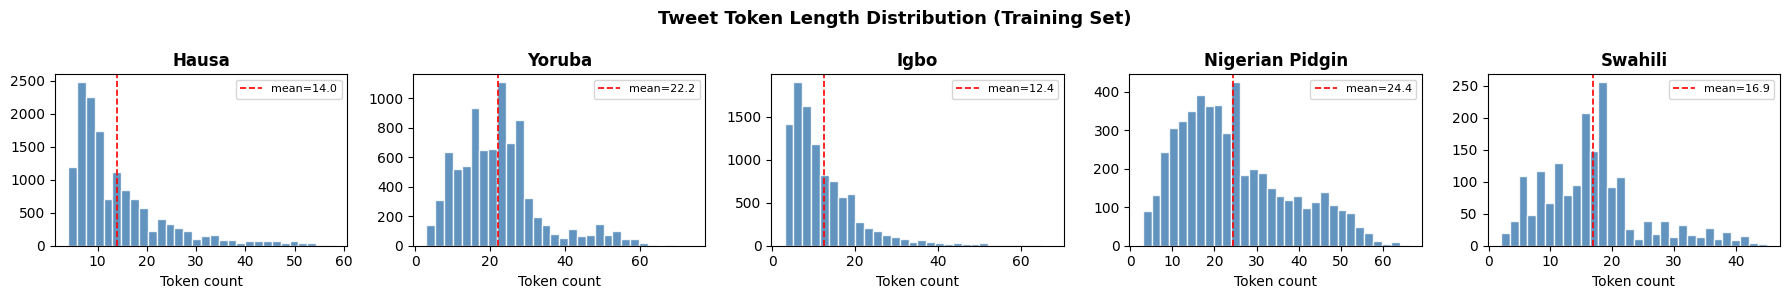

In [22]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
fig.suptitle('Tweet Token Length Distribution (Training Set)', fontsize=13, fontweight='bold')

for ax, (iso, cfg) in zip(axes, LANGUAGES.items()):
    lengths = all_data[iso]['train']['tweet'].str.split().str.len()
    ax.hist(lengths, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(lengths.mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'mean={lengths.mean():.1f}')
    ax.set_title(cfg['name'], fontweight='bold')
    ax.set_xlabel('Token count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'tweet_lengths.png', dpi=150, bbox_inches='tight')
plt.show()


## 1.5 EDA — Class Imbalance

In [23]:
print(f"{'Language':<20} {'Majority':>10} {'Minority':>10} {'Ratio':>8}")
print("-"*52)
for iso, cfg in LANGUAGES.items():
    counts = all_data[iso]['train']['label'].value_counts()
    ratio = counts.iloc[0] / counts.iloc[-1]
    print(f"{cfg['name']:<20} {counts.index[0]:>10} {counts.index[-1]:>10} {ratio:>8.2f}x")


Language               Majority   Minority    Ratio
----------------------------------------------------
Hausa                   neutral   negative     1.07x
Yoruba                 positive   negative     1.89x
Igbo                    neutral   negative     1.73x
Nigerian Pidgin        negative    neutral    45.01x
Swahili                 neutral   negative     5.61x


## 1.6 Code-Mixing Filter

In [ ]:
from multiprocessing.pool import ThreadPool


def english_token_ratio(text: str) -> float:
    tokens = text.split()
    if not tokens:
        return 0.0
    count = 0
    for token in tokens:
        t = re.sub(r'[^a-zA-Z]', '', token)
        if len(t) < 3:
            continue
        try:
            langs = detect_langs(t)
            if any(l.lang == 'en' and l.prob > 0.5 for l in langs):
                count += 1
        except BaseException:
            pass
    return count / len(tokens)


def add_codemix_flag(df: pd.DataFrame, threshold: float = 0.20) -> pd.DataFrame:
    df = df.copy()
    with ThreadPool(processes=4) as pool:
        df['en_ratio'] = pool.map(english_token_ratio, df['tweet'].tolist())
    df['is_codemixed'] = df['en_ratio'] > threshold
    return df


print("Applying code-mixing filter to all test sets...")
for iso in LANGUAGES:
    all_data[iso]['test'] = add_codemix_flag(all_data[iso]['test'])
    cm = all_data[iso]['test']['is_codemixed'].sum()
    tot = len(all_data[iso]['test'])
    print(f"  {LANGUAGES[iso]['name']:<20} code-mixed: {cm}/{tot} ({100*cm/tot:.1f}%)")

print("\n✅ Code-mixing filter applied.")


Applying code-mixing filter to all test sets...
  Hausa                code-mixed: 7/5303 (0.1%)


## 1.7 Shared Dataset Class & Metrics
*(Used by all models below)*

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['tweet'].tolist()
        self.labels = df['label_id'].tolist()
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], max_length=self.max_len,
                       padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids':      enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'labels':         torch.tensor(self.labels[idx], dtype=torch.long)}


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {'weighted_f1': f1_score(labels, preds, average='weighted', zero_division=0),
            'macro_f1':    f1_score(labels, preds, average='macro',    zero_division=0)}


def evaluate_subset(model, tokenizer, df_sub, device, name, bs=32):
    if df_sub.empty:
        print(f"  [{name}] empty — skip")
        return None
    ds = SentimentDataset(df_sub, tokenizer)
    ldr = DataLoader(ds, batch_size=bs)
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for batch in ldr:
            out = model(input_ids=batch['input_ids'].to(device),
                        attention_mask=batch['attention_mask'].to(device))
            all_p.extend(torch.argmax(out.logits, dim=-1).cpu().numpy())
            all_l.extend(batch['labels'].numpy())
    wf1 = f1_score(all_l, all_p, average='weighted', zero_division=0)
    mf1 = f1_score(all_l, all_p, average='macro',    zero_division=0)
    print(f"  [{name}] wF1={wf1:.4f}  mF1={mf1:.4f}  n={len(all_l)}")
    return {'weighted_f1': round(wf1, 4), 'macro_f1': round(mf1, 4), 'n': len(all_l)}


print("✅ Shared classes and metrics ready.")


## 1.8 TF-IDF + Logistic Regression Baseline

In [ ]:
def run_tfidf(iso: str, data: dict, results: dict) -> dict:
    print(f"\n{'─'*50}\n  TF-IDF | {LANGUAGES[iso]['name']}\n{'─'*50}")
    seed_wf1, seed_mf1 = [], []

    for seed in SEEDS:
        key = f"tfidf_{iso}_seed{seed}"
        if key in results:
            print(f"  Seed {seed}: cached")
            seed_wf1.append(results[key]['test_weighted_f1'])
            seed_mf1.append(results[key]['test_macro_f1'])
            continue

        set_all_seeds(seed)
        vec = TfidfVectorizer(ngram_range=(1, 2), max_features=50_000,
                              sublinear_tf=True, strip_accents=None)
        X_tr = vec.fit_transform(data['train']['tweet'])
        X_va = vec.transform(data['val']['tweet'])
        X_te = vec.transform(data['test']['tweet'])
        y_tr = data['train']['label_id']
        y_va = data['val']['label_id']
        y_te = data['test']['label_id']

        clf = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                                 multi_class='multinomial', random_state=seed)
        clf.fit(X_tr, y_tr)
        preds = clf.predict(X_te)
        test_wf1 = f1_score(y_te, preds, average='weighted', zero_division=0)
        test_mf1 = f1_score(y_te, preds, average='macro',    zero_division=0)

        test_df = data['test']
        mono_idx = test_df[~test_df['is_codemixed']].index
        mixed_idx = test_df[test_df['is_codemixed']].index
        mono_wf1 = f1_score(
            y_te[mono_idx],
            preds[mono_idx],
            average='weighted',
            zero_division=0) if len(mono_idx) else None
        mixed_wf1 = f1_score(
            y_te[mixed_idx],
            preds[mixed_idx],
            average='weighted',
            zero_division=0) if len(mixed_idx) else None

        print(f"  Seed {seed}: wF1={test_wf1:.4f}  "
              f"mono={f'{mono_wf1:.4f}' if mono_wf1 else '—'}  "
              f"mixed={f'{mixed_wf1:.4f}' if mixed_wf1 else '—'}")

        results[key] = {
            'model': 'TF-IDF+LR', 'iso': iso, 'seed': seed,
            'test_weighted_f1': round(test_wf1, 4),
            'test_macro_f1':    round(test_mf1, 4),
            'codemix_mono':     round(mono_wf1,  4) if mono_wf1 else None,
            'codemix_mixed':    round(mixed_wf1, 4) if mixed_wf1 else None,
            'timestamp': datetime.now().isoformat(),
        }
        save_results(results)
        seed_wf1.append(test_wf1)
        seed_mf1.append(test_mf1)

    print(f"  MEAN: wF1={np.mean(seed_wf1):.4f} ± {np.std(seed_wf1):.4f}")
    return results


results = load_results()
for iso in LANGUAGES:
    results = run_tfidf(iso, all_data[iso], results)


In [ ]:
# TF-IDF Summary
print(f"\n{'='*60}\nTF-IDF SUMMARY (mean ± std, 3 seeds)\n{'='*60}")
print(f"{'Language':<20} {'Weighted F1':>17} {'Macro F1':>14}")
print("-"*54)
for iso, cfg in LANGUAGES.items():
    wf1 = [results[f'tfidf_{iso}_seed{s}']['test_weighted_f1'] for s in SEEDS if f'tfidf_{iso}_seed{s}' in results]
    mf1 = [results[f'tfidf_{iso}_seed{s}']['test_macro_f1'] for s in SEEDS if f'tfidf_{iso}_seed{s}' in results]
    if wf1:
        print(f"{cfg['name']:<20} {np.mean(wf1):.4f} ± {np.std(wf1):.4f}  {np.mean(mf1):.4f} ± {np.std(mf1):.4f}")

print("\n🎉 Phase 1 complete.")


In [ ]:
results = load_results()
keys_to_keep = [k for k in results if k.startswith('tfidf')]
results = {k: results[k] for k in keys_to_keep}
print(f"Kept {len(results)} tfidf keys, cleared the rest.")
print(list(results.keys()))


---
# Phase 2 — LAFT: Monolingual AfroXLMR Fine-Tuning

In [ ]:
AFROXLMR_MODEL = 'Davlan/afro-xlmr-base'
MAX_LEN = 128
BATCH_SIZE = 16    # AfroXLMR on T4
GRAD_ACCUM = 2     # effective batch = 32
EPOCHS = 10
LR = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
PATIENCE = 3
print("✅ LAFT config set.")


## 2.1 LAFT Training Function

In [ ]:
# CleanUP checkpoints folder
import shutil
for iso in LANGUAGES:
    for seed in SEEDS:
        ckpt = SAVE_DIR / f'ckpt_laft_{iso}_seed{seed}'
        shutil.rmtree(ckpt, ignore_errors=True)

total, used, free = shutil.disk_usage("/kaggle/working/")
print(f"Free: {free / 1e9:.1f} GB")


In [ ]:
def run_laft(iso: str, seed: int, data: dict, results: dict) -> dict:
    key = f"laft_{iso}_seed{seed}"
    if key in results:
        print(f"  Skipping {key} (cached)")
        return results

    print(f"\n{'─'*55}\n  LAFT | {LANGUAGES[iso]['name']} | seed={seed}")
    print(f"  train={len(data['train'])}  val={len(data['val'])}  test={len(data['test'])}\n{'─'*55}")
    set_all_seeds(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"  Device: {device}")

    tokenizer = AutoTokenizer.from_pretrained(AFROXLMR_MODEL)
    model = AutoModelForSequenceClassification.from_pretrained(
        AFROXLMR_MODEL, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID).to(device)

    train_ds = SentimentDataset(data['train'], tokenizer, MAX_LEN)
    val_ds = SentimentDataset(data['val'],   tokenizer, MAX_LEN)
    test_ds = SentimentDataset(data['test'],  tokenizer, MAX_LEN)

    args = TrainingArguments(
        output_dir=str(SAVE_DIR / f'ckpt_laft_{iso}_seed{seed}'),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        per_device_eval_batch_size=32,
        learning_rate=LR, warmup_ratio=WARMUP_RATIO, weight_decay=WEIGHT_DECAY,
        eval_strategy='epoch', save_strategy='epoch',
        load_best_model_at_end=True, metric_for_best_model='weighted_f1',
        greater_is_better=True, logging_steps=50,
        fp16=torch.cuda.is_available(), report_to='none', save_total_limit=1,
    )
    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
    )
    trainer.train()

    out = trainer.predict(test_ds)
    preds = np.argmax(out.predictions, axis=-1)
    labels = out.label_ids
    wf1 = f1_score(labels, preds, average='weighted', zero_division=0)
    mf1 = f1_score(labels, preds, average='macro',    zero_division=0)
    print(f"\n  Test wF1={wf1:.4f}  mF1={mf1:.4f}")
    print(classification_report(labels, preds, target_names=list(LABEL2ID.keys()), zero_division=0))

    mono_m = evaluate_subset(model, tokenizer, data['test'][~data['test']['is_codemixed']], device, 'monolingual')
    mixed_m = evaluate_subset(model, tokenizer, data['test'][data['test']['is_codemixed']], device, 'code-mixed')

    cm_mat = confusion_matrix(labels, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_mat, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(LABEL2ID.keys()), yticklabels=list(LABEL2ID.keys()))
    plt.title(f'LAFT — {LANGUAGES[iso]["name"]} (seed={seed})')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(SAVE_DIR / f'cm_laft_{iso}_seed{seed}.png', dpi=120)
    plt.show()

    results[key] = {
        'model': 'LAFT_AfroXLMR', 'iso': iso, 'seed': seed,
        'test_weighted_f1': round(wf1, 4), 'test_macro_f1': round(mf1, 4),
        'n_test': len(labels), 'codemix_mono': mono_m, 'codemix_mixed': mixed_m,
        'timestamp': datetime.now().isoformat(),
    }
    save_results(results)

    # Save just the best model weights, delete the bulky checkpoint
    best = best_model_for_lang(iso, results)
    if best and best['seed'] == seed and best['model_prefix'] == 'laft':
        model.save_pretrained(SAVE_DIR / f'best_laft_{iso}')
        tokenizer.save_pretrained(SAVE_DIR / f'best_laft_{iso}')
        shutil.rmtree(SAVE_DIR / f'ckpt_laft_{iso}_seed{seed}', ignore_errors=True)

        del model, trainer
        torch.cuda.empty_cache()
        return results


## 2.2 Run LAFT — All Languages
> Each seed saves to Drive immediately. If Colab disconnects, re-run this cell — completed seeds are skipped automatically.

In [ ]:

for iso in LANGUAGES:
    print(f"\n{'#'*55}\n# {LANGUAGES[iso]['name']} ({iso})\n{'#'*55}")
    for seed in SEEDS:
        results = run_laft(iso, seed, all_data[iso], results)
    print(f"\n✅ {LANGUAGES[iso]['name']} — all seeds done.")


## 2.3 LAFT Summary

In [ ]:
import shutil
total, used, free = shutil.disk_usage("/kaggle/working/")
print(f"Free: {free / 1e9:.1f} GB")


In [ ]:
print(f"\n{'='*60}\nLAFT SUMMARY (mean ± std, 3 seeds)\n{'='*60}")
print(f"{'Language':<20} {'Weighted F1':>17} {'Macro F1':>14}")
print("-"*54)
for iso, cfg in LANGUAGES.items():
    wf1 = [results[f'laft_{iso}_seed{s}']['test_weighted_f1'] for s in SEEDS if f'laft_{iso}_seed{s}' in results]
    mf1 = [results[f'laft_{iso}_seed{s}']['test_macro_f1'] for s in SEEDS if f'laft_{iso}_seed{s}' in results]
    if wf1:
        print(f"{cfg['name']:<20} {np.mean(wf1):.4f} ± {np.std(wf1):.4f}  {np.mean(mf1):.4f} ± {np.std(mf1):.4f}")

print("\n🎉 Phase 2 (LAFT) complete.")


---
# Phase 3 — mBERT & MAFT

In [ ]:
# CleanUP checkpoints folder
import shutil
for iso in LANGUAGES:
    for seed in SEEDS:
        ckpt = SAVE_DIR / f'ckpt_laft_{iso}_seed{seed}'
        shutil.rmtree(ckpt, ignore_errors=True)

total, used, free = shutil.disk_usage("/kaggle/working/")
print(f"Free: {free / 1e9:.1f} GB")


In [ ]:
MBERT_MODEL = 'bert-base-multilingual-cased'
MBERT_BATCH = 32    # mBERT is smaller — fits batch=32 on T4
MAFT_BATCH = 16    # AfroXLMR needs smaller batch
# MAX_LEN, GRAD_ACCUM, EPOCHS, LR, WARMUP_RATIO, WEIGHT_DECAY, PATIENCE
# all inherited from Phase 2 config cell above
print("✅ Phase 3 config set.")


## 3.1 mBERT Fine-Tuning (per language)

In [ ]:
def run_mbert(iso: str, seed: int, data: dict, results: dict) -> dict:
    key = f"mbert_{iso}_seed{seed}"
    if key in results:
        print(f"  Skipping {key} (cached)")
        return results

    print(f"\n{'─'*55}\n  mBERT | {LANGUAGES[iso]['name']} | seed={seed}\n{'─'*55}")
    set_all_seeds(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    tokenizer = AutoTokenizer.from_pretrained(MBERT_MODEL)
    model = AutoModelForSequenceClassification.from_pretrained(
        MBERT_MODEL, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID).to(device)

    train_ds = SentimentDataset(data['train'], tokenizer, MAX_LEN)
    val_ds = SentimentDataset(data['val'],   tokenizer, MAX_LEN)
    test_ds = SentimentDataset(data['test'],  tokenizer, MAX_LEN)

    args = TrainingArguments(
        output_dir=str(SAVE_DIR / f'ckpt_mbert_{iso}_seed{seed}'),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=MBERT_BATCH,
        per_device_eval_batch_size=32,
        learning_rate=LR, warmup_ratio=WARMUP_RATIO, weight_decay=WEIGHT_DECAY,
        eval_strategy='epoch', save_strategy='epoch',
        load_best_model_at_end=True, metric_for_best_model='weighted_f1',
        greater_is_better=True, logging_steps=50,
        fp16=torch.cuda.is_available(), report_to='none', save_total_limit=1,
    )
    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
    )
    trainer.train()

    out = trainer.predict(test_ds)
    preds = np.argmax(out.predictions, axis=-1)
    labels = out.label_ids
    wf1 = f1_score(labels, preds, average='weighted', zero_division=0)
    mf1 = f1_score(labels, preds, average='macro',    zero_division=0)
    print(f"\n  Test wF1={wf1:.4f}  mF1={mf1:.4f}")
    print(classification_report(labels, preds, target_names=list(LABEL2ID.keys()), zero_division=0))

    mono_m = evaluate_subset(model, tokenizer, data['test'][~data['test']['is_codemixed']], device, 'monolingual')
    mixed_m = evaluate_subset(model, tokenizer, data['test'][data['test']['is_codemixed']], device, 'code-mixed')

    results[key] = {
        'model': 'mBERT', 'iso': iso, 'seed': seed,
        'test_weighted_f1': round(wf1, 4), 'test_macro_f1': round(mf1, 4),
        'n_test': len(labels), 'codemix_mono': mono_m, 'codemix_mixed': mixed_m,
        'timestamp': datetime.now().isoformat(),
    }
    save_results(results)

    best = best_model_for_lang(iso, results)
    if best and best['seed'] == seed and best['model_prefix'] == 'mbert':
        model.save_pretrained(SAVE_DIR / f'best_mbert_{iso}')
        tokenizer.save_pretrained(SAVE_DIR / f'best_mbert_{iso}')
    shutil.rmtree(SAVE_DIR / f'ckpt_mbert_{iso}_seed{seed}', ignore_errors=True)

    del model, trainer
    torch.cuda.empty_cache()
    return results


## 3.2 Run mBERT — All Languages

In [ ]:

for iso in LANGUAGES:
    print(f"\n{'#'*55}\n# {LANGUAGES[iso]['name']} ({iso})\n{'#'*55}")
    for seed in SEEDS:
        results = run_mbert(iso, seed, all_data[iso], results)
    print(f"\n✅ {LANGUAGES[iso]['name']} done.")


## 3.3 mBERT Summary

In [ ]:
print(f"\n{'='*60}\nmBERT SUMMARY (mean ± std, 3 seeds)\n{'='*60}")
print(f"{'Language':<20} {'Weighted F1':>17} {'Macro F1':>14}")
print("-"*54)
for iso, cfg in LANGUAGES.items():
    wf1 = [results[f'mbert_{iso}_seed{s}']['test_weighted_f1'] for s in SEEDS if f'mbert_{iso}_seed{s}' in results]
    mf1 = [results[f'mbert_{iso}_seed{s}']['test_macro_f1'] for s in SEEDS if f'mbert_{iso}_seed{s}' in results]
    if wf1:
        print(f"{cfg['name']:<20} {np.mean(wf1):.4f} ± {np.std(wf1):.4f}  {np.mean(mf1):.4f} ± {np.std(mf1):.4f}")


## 3.4 MAFT — Multilingual Joint AfroXLMR

In [ ]:
class MultilingualDataset(Dataset):
    def __init__(self, lang_data, split, tokenizer, max_len=128):
        frames = []
        for iso, data in lang_data.items():
            df = data[split].copy()
            df['iso'] = iso
            frames.append(df)
        self.df = pd.concat(frames, ignore_index=True)
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        enc = self.tok(row['tweet'], max_length=self.max_len,
                       padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids':      enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'labels':         torch.tensor(row['label_id'], dtype=torch.long)}


def evaluate_maft_per_language(model, tokenizer, all_data, device):
    per_lang = {}
    for iso, data in all_data.items():
        print(f"\n  Evaluating {LANGUAGES[iso]['name']}...")
        ds = SentimentDataset(data['test'], tokenizer, MAX_LEN)
        ldr = DataLoader(ds, batch_size=32)
        model.eval()
        all_p, all_l = [], []
        with torch.no_grad():
            for batch in ldr:
                out = model(input_ids=batch['input_ids'].to(device),
                            attention_mask=batch['attention_mask'].to(device))
                all_p.extend(torch.argmax(out.logits, dim=-1).cpu().numpy())
                all_l.extend(batch['labels'].numpy())
        wf1 = f1_score(all_l, all_p, average='weighted', zero_division=0)
        mf1 = f1_score(all_l, all_p, average='macro',    zero_division=0)
        print(f"    wF1={wf1:.4f}  mF1={mf1:.4f}  n={len(all_l)}")
        print(classification_report(all_l, all_p, target_names=list(LABEL2ID.keys()), zero_division=0))
        mono_m = evaluate_subset(model, tokenizer, data['test'][~data['test']['is_codemixed']], device, 'monolingual')
        mixed_m = evaluate_subset(model, tokenizer, data['test'][data['test']['is_codemixed']], device, 'code-mixed')
        per_lang[iso] = {'weighted_f1': round(wf1, 4), 'macro_f1': round(mf1, 4),
                         'n': len(all_l), 'codemix_mono': mono_m, 'codemix_mixed': mixed_m}
    return per_lang


def run_maft(seed: int, all_data: dict, results: dict) -> dict:
    key = f"maft_all_seed{seed}"
    if key in results:
        print(f"  Skipping {key} (cached)")
        return results

    print(f"\n{'─'*55}\n  MAFT | All 5 languages | seed={seed}\n{'─'*55}")
    set_all_seeds(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    tokenizer = AutoTokenizer.from_pretrained(AFROXLMR_MODEL)
    model = AutoModelForSequenceClassification.from_pretrained(
        AFROXLMR_MODEL, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID).to(device)

    train_ds = MultilingualDataset(all_data, 'train', tokenizer, MAX_LEN)
    val_ds = MultilingualDataset(all_data, 'val',   tokenizer, MAX_LEN)
    print(f"  Joint train: {len(train_ds)}  val: {len(val_ds)}")

    args = TrainingArguments(
        output_dir=str(SAVE_DIR / f'ckpt_maft_seed{seed}'),
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=MAFT_BATCH,
        gradient_accumulation_steps=GRAD_ACCUM,
        per_device_eval_batch_size=32,
        learning_rate=LR, warmup_ratio=WARMUP_RATIO, weight_decay=WEIGHT_DECAY,
        eval_strategy='epoch', save_strategy='epoch',
        load_best_model_at_end=True, metric_for_best_model='weighted_f1',
        greater_is_better=True, logging_steps=100,
        fp16=torch.cuda.is_available(), report_to='none', save_total_limit=1,
    )
    trainer = Trainer(
        model=model, args=args,
        train_dataset=train_ds, eval_dataset=val_ds,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENCE)],
    )
    trainer.train()

    per_lang = evaluate_maft_per_language(model, tokenizer, all_data, device)
    total_n = sum(v['n'] for v in per_lang.values())
    overall = sum(v['weighted_f1'] * v['n'] for v in per_lang.values()) / total_n
    print(f"\n  Overall size-weighted wF1: {overall:.4f}")

    results[key] = {
        'model': 'MAFT_AfroXLMR', 'seed': seed,
        'per_language': per_lang, 'overall_weighted_f1': round(overall, 4),
        'timestamp': datetime.now().isoformat(),
    }
    save_results(results)

    best_seed = max(SEEDS, key=lambda s: results.get(f'maft_all_seed{s}', {}).get('overall_weighted_f1', 0))
    if seed == best_seed:
        model.save_pretrained(SAVE_DIR / f'best_maft')
        tokenizer.save_pretrained(SAVE_DIR / f'best_maft')
    shutil.rmtree(SAVE_DIR / f'ckpt_maft_seed{seed}', ignore_errors=True)

    del model, trainer
    torch.cuda.empty_cache()
    return results


print("✅ MAFT functions defined.")


## 3.5 Run MAFT — All Seeds

In [ ]:
# CleanUP checkpoints folder
import shutil
for iso in LANGUAGES:
    for seed in SEEDS:
        ckpt = SAVE_DIR / f'ckpt_laft_{iso}_seed{seed}'
        shutil.rmtree(ckpt, ignore_errors=True)

total, used, free = shutil.disk_usage("/kaggle/working/")
print(f"Free: {free / 1e9:.1f} GB")


In [ ]:
for seed in SEEDS:
    results = run_maft(seed, all_data, results)


## 3.6 MAFT Summary

In [ ]:
print(f"\n{'='*60}\nMAFT SUMMARY (mean ± std, 3 seeds)\n{'='*60}")
print(f"{'Language':<20} {'Weighted F1':>17} {'Macro F1':>14}")
print("-"*54)
for iso, cfg in LANGUAGES.items():
    wf1 = [results[f'maft_all_seed{s}']['per_language'][iso]['weighted_f1']
           for s in SEEDS if f'maft_all_seed{s}' in results
           and iso in results[f'maft_all_seed{s}'].get('per_language', {})]
    mf1 = [results[f'maft_all_seed{s}']['per_language'][iso]['macro_f1']
           for s in SEEDS if f'maft_all_seed{s}' in results
           and iso in results[f'maft_all_seed{s}'].get('per_language', {})]
    if wf1:
        print(f"{cfg['name']:<20} {np.mean(wf1):.4f} ± {np.std(wf1):.4f}  {np.mean(mf1):.4f} ± {np.std(mf1):.4f}")

print("\n🎉 Phase 3 complete.")


---
# Full Results Comparison
**All 4 models — TF-IDF · mBERT · LAFT · MAFT**

In [ ]:
print(f"\n{'='*70}")
print("FULL RESULTS COMPARISON (mean weighted F1 across 3 seeds)")
print(f"{'='*70}")
print(f"{'Language':<18} {'TF-IDF':>8} {'mBERT':>8} {'LAFT':>8} {'MAFT':>8} {'MAFT-LAFT':>10}")
print("-"*62)

for iso, cfg in LANGUAGES.items():
    def mean_wf1(prefix):
        if prefix == 'maft':
            vals = [results[f'maft_all_seed{s}']['per_language'][iso]['weighted_f1']
                    for s in SEEDS if f'maft_all_seed{s}' in results
                    and iso in results[f'maft_all_seed{s}'].get('per_language', {})]
        else:
            vals = [results[f'{prefix}_{iso}_seed{s}']['test_weighted_f1']
                    for s in SEEDS if f'{prefix}_{iso}_seed{s}' in results]
        return np.mean(vals) if vals else None

    tf = mean_wf1('tfidf')
    mb = mean_wf1('mbert')
    la = mean_wf1('laft')
    ma = mean_wf1('maft')
    delta = f"{ma - la:+.4f}" if ma and la else '—'

    print(f"{cfg['name']:<18} "
          f"{f'{tf:.4f}' if tf else '—':>8} "
          f"{f'{mb:.4f}' if mb else '—':>8} "
          f"{f'{la:.4f}' if la else '—':>8} "
          f"{f'{ma:.4f}' if ma else '—':>8} "
          f"{delta:>10}")

print("\n✅ All results loaded from Drive.")


---
# Phase 4 — LIME Error Analysis
**Interpretability · Error Diagnosis · Cross-Model Comparison**

This phase applies LIME (Local Interpretable Model-Agnostic Explanations) to understand *why* models make mistakes.
We analyse the **best model per language** (selected from LAFT/MAFT/mBERT by weighted F1), surface systematic error patterns,
and compare how the best transformer model differs from the TF-IDF baseline in its failure modes.


In [ ]:
# ── Phase 4 Setup ──────────────────────────────────────────────────
import warnings
import random
import re
import json
import os
from lime.lime_text import LimeTextExplainer
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, set_seed
from torch.utils.data import Dataset, DataLoader
import torch
from collections import defaultdict, Counter
from datetime import datetime
from pathlib import Path
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
!pip install - q lime


warnings.filterwarnings('ignore')

RESULTS_PATH = Path(
    "/kaggle/input/datasets/praisesobi/group60-nlp/group60_nlp-20260521T223451Z-3-002/group60_nlp-20260521T223451Z-3-002/group60_nlp/all_results.json")
CKPT_ROOT = CKPT_ROOT = Path('/kaggle/working')  # adjust if checkpoints are in a separate dataset
OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LABEL2ID = {'positive': 0, 'negative': 1, 'neutral': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
SEEDS = [42, 123, 456]
LANGUAGES = {
    'hau': {'name': 'Hausa',           'family': 'Afro-Asiatic',   'region': 'West Africa'},
    'yor': {'name': 'Yoruba',          'family': 'Niger-Congo',    'region': 'West Africa'},
    'ibo': {'name': 'Igbo',            'family': 'Niger-Congo',    'region': 'West Africa'},
    'pcm': {'name': 'Nigerian Pidgin', 'family': 'English Creole', 'region': 'West Africa'},
    'swa': {'name': 'Swahili',         'family': 'Niger-Congo',    'region': 'East Africa'},
}


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    set_seed(seed)


print("✅ Phase 4 imports done.")


## 4.1 Reload Data & Results

In [ ]:
# ── Re-download AfriSenti data (same as Phase 1) ──────────────────
from langdetect import detect_langs
from multiprocessing.pool import ThreadPool
base = "https://raw.githubusercontent.com/afrisenti-semeval/afrisent-semeval-2023/main/data/{lang}/{split}.tsv"


def download_split(lang_iso, split):
    url = base.format(lang=lang_iso, split=split)
    df = pd.read_csv(url, sep='\t', header=None, names=['tweet', 'label'], on_bad_lines='skip')
    df = df.dropna(subset=['tweet', 'label'])
    df['label'] = df['label'].str.strip().str.lower()
    df = df[df['label'].isin(LABEL2ID)].copy()
    df['label_id'] = df['label'].map(LABEL2ID)
    df['iso'] = lang_iso
    return df.reset_index(drop=True)


all_data = {}
for iso in LANGUAGES:
    print(f"  Downloading {LANGUAGES[iso]['name']}...")
    all_data[iso] = {
        'train': download_split(iso, 'train'),
        'val':   download_split(iso, 'dev'),
        'test':  download_split(iso, 'test'),
    }

# Add code-mix flag to test sets


def english_token_ratio(text):
    tokens = text.split()
    if not tokens:
        return 0.0
    count = 0
    for token in tokens:
        t = re.sub(r'[^a-zA-Z]', '', token)
        if len(t) < 3:
            continue
        try:
            langs = detect_langs(t)
            if any(l.lang == 'en' and l.prob > 0.5 for l in langs):
                count += 1
        except BaseException:
            pass
    return count / len(tokens)


def add_codemix_flag(df, threshold=0.20):
    df = df.copy()
    with ThreadPool(processes=4) as pool:
        df['en_ratio'] = pool.map(english_token_ratio, df['tweet'].tolist())
    df['is_codemixed'] = df['en_ratio'] > threshold
    return df


for iso in LANGUAGES:
    all_data[iso]['test'] = add_codemix_flag(all_data[iso]['test'])

# Load saved results
results = json.loads(RESULTS_PATH.read_text()) if RESULTS_PATH.exists() else {}
print(f"\n✅ Data loaded. Results keys: {len(results)}")


## 4.2 Select Best Model per Language

In [ ]:
# Pick the seed with highest weighted F1 per language, prefer LAFT > MAFT > mBERT
def best_model_for_lang(iso, results):
    candidates = []
    for model_prefix, model_name in [('laft', 'LAFT'), ('maft', 'MAFT'), ('mbert', 'mBERT')]:
        for seed in SEEDS:
            if model_prefix == 'maft':
                key = f'maft_all_seed{seed}'
                if key in results and iso in results[key].get('per_language', {}):
                    wf1 = results[key]['per_language'][iso]['weighted_f1']
                    candidates.append((wf1, model_prefix, model_name, seed, key))
            else:
                key = f'{model_prefix}_{iso}_seed{seed}'
                if key in results:
                    wf1 = results[key]['test_weighted_f1']
                    candidates.append((wf1, model_prefix, model_name, seed, key))
    if not candidates:
        return None
    candidates.sort(reverse=True)
    best = candidates[0]
    return {'wf1': best[0], 'model_prefix': best[1], 'model_name': best[2],
            'seed': best[3], 'key': best[4]}


best_models = {}
print(f"{'Language':<20} {'Best Model':<12} {'Seed':>6} {'Weighted F1':>13}")
print("-" * 55)
for iso, cfg in LANGUAGES.items():
    bm = best_model_for_lang(iso, results)
    best_models[iso] = bm
    if bm:
        print(f"{cfg['name']:<20} {bm['model_name']:<12} {bm['seed']:>6} {bm['wf1']:>13.4f}")
    else:
        print(f"{cfg['name']:<20} {'No results found':>32}")

print("\n✅ Best models identified.")


## 4.3 Shared Dataset Class

In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df['tweet'].tolist()
        self.labels = df['label_id'].tolist()
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tok(self.texts[idx], max_length=self.max_len,
                       padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids':      enc['input_ids'].squeeze(),
                'attention_mask': enc['attention_mask'].squeeze(),
                'labels':         torch.tensor(self.labels[idx], dtype=torch.long)}


print("✅ SentimentDataset ready.")


## 4.4 LIME Error Analysis — Per Language

For each language we:
1. Load the best checkpoint from `/kaggle/input/...`
2. Run inference on the full test set, separate correct vs incorrect predictions
3. Sample up to **30 misclassified** examples for LIME explanations
4. Aggregate token-level feature importances to find systematic failure patterns
5. Repeat for the TF-IDF baseline for comparison


In [ ]:
from transformers import XLMRobertaForSequenceClassification, BertForSequenceClassification


def get_ckpt_dir(base_dir):
    """Find the actual checkpoint inside a trainer output dir."""
    if not base_dir.exists():
        return base_dir
    subdirs = [d for d in base_dir.iterdir() if d.is_dir() and d.name.startswith('checkpoint-')]
    if subdirs:
        return max(subdirs, key=lambda x: int(x.name.split('-')[1]))
    return base_dir


def get_transformer_predictor(model, tokenizer, device, max_len=128):
    """Returns a predict_proba function LIME can call."""
    def predictor(texts):
        model.eval()
        probs = []
        for i in range(0, len(texts), 16):
            batch_texts = texts[i:i+16]
            enc = tokenizer(batch_texts, max_length=max_len, padding=True,
                            truncation=True, return_tensors='pt').to(device)
            with torch.no_grad():
                logits = model(**enc).logits
            probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
        return np.vstack(probs)
    return predictor


def run_lime_analysis(iso, model_info, all_data, results,
                      n_lime_samples=30, n_lime_features=10, lime_perturb=500):
    """
    Full LIME error analysis for one language.
    Returns a dict with error df, top bad tokens, and lime explanation objects.
    """
    print(f"\n{'='*60}")
    print(f"  LIME Analysis: {LANGUAGES[iso]['name']} | {model_info['model_name']} seed={model_info['seed']}")
    print(f"{'='*60}")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    test_df = all_data[iso]['test'].copy().reset_index(drop=True)
    model_pfx = model_info['model_prefix']

    # ── Load model & tokenizer ──────────────────────────────────────
    if model_pfx == 'maft':
        model_name_hf = 'Davlan/afro-xlmr-base'
        ckpt_dir = CKPT_ROOT / 'best_maft'
    elif model_pfx == 'laft':
        model_name_hf = 'Davlan/afro-xlmr-base'
        ckpt_dir = CKPT_ROOT / f'best_laft_{iso}'
    else:
        model_name_hf = 'bert-base-multilingual-cased'
        ckpt_dir = CKPT_ROOT / f'best_mbert_{iso}'

    tokenizer = AutoTokenizer.from_pretrained(model_name_hf)

    # Pick the right model class based on architecture
    is_mbert = model_pfx == 'mbert'
    ModelClass = BertForSequenceClassification if is_mbert else XLMRobertaForSequenceClassification

    # Try loading from saved checkpoint, fall back to base weights
    if ckpt_dir.exists():
        print(f"  Loading checkpoint: {ckpt_dir}")
        model = ModelClass.from_pretrained(
            str(ckpt_dir), num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID,
            ignore_mismatched_sizes=True).to(device)
    else:
        print(f"  ⚠️  Checkpoint not found at {ckpt_dir}. Loading base weights (results will differ from training).")
        model = ModelClass.from_pretrained(
            model_name_hf, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID).to(device)

    # ── Full inference on test set ──────────────────────────────────
    ds = SentimentDataset(test_df, tokenizer)
    ldr = DataLoader(ds, batch_size=32)
    model.eval()
    all_preds, all_probs = [], []
    with torch.no_grad():
        for batch in ldr:
            out = model(input_ids=batch['input_ids'].to(device),
                        attention_mask=batch['attention_mask'].to(device))
            probs = torch.softmax(out.logits, dim=-1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(np.argmax(probs, axis=-1))

    test_df['pred_id'] = all_preds
    test_df['pred_label'] = [ID2LABEL[p] for p in all_preds]
    test_df['confidence'] = [max(p) for p in all_probs]
    test_df['correct'] = test_df['pred_id'] == test_df['label_id']

    wf1 = f1_score(test_df['label_id'], test_df['pred_id'], average='weighted', zero_division=0)
    print(f"  Inference done. wF1={wf1:.4f}  errors={int((~test_df['correct']).sum())}/{len(test_df)}")

    # ── Classify error types ────────────────────────────────────────
    errors_df = test_df[~test_df['correct']].copy()
    errors_df['error_type'] = errors_df['label'] + '→' + errors_df['pred_label']

    print(f"\n  Error type breakdown:")
    for et, cnt in errors_df['error_type'].value_counts().items():
        print(f"    {et}: {cnt}")

    # ── Sample for LIME ─────────────────────────────────────────────
    sample_df = errors_df.sample(min(n_lime_samples, len(errors_df)), random_state=42)
    predictor = get_transformer_predictor(model, tokenizer, device)
    explainer = LimeTextExplainer(class_names=['positive', 'negative', 'neutral'])

    lime_results = []
    token_neg_total = defaultdict(float)   # tokens that pushed toward wrong class
    token_pos_total = defaultdict(float)   # tokens that pushed toward correct class

    print(f"\n  Running LIME on {len(sample_df)} misclassified examples...")
    for idx, row in enumerate(sample_df.itertuples()):
        try:
            exp = explainer.explain_instance(
                row.tweet,
                predictor,
                num_features=n_lime_features,
                num_samples=lime_perturb,
                labels=[row.pred_id, row.label_id],
            )
            # Features for predicted (wrong) class
            for token, weight in exp.as_list(label=row.pred_id):
                token_clean = token.lower().strip()
                if weight > 0:
                    token_neg_total[token_clean] += weight   # pushed toward wrong
            # Features for true class
            for token, weight in exp.as_list(label=row.label_id):
                token_clean = token.lower().strip()
                if weight > 0:
                    token_pos_total[token_clean] += weight

            lime_results.append({
                'tweet':       row.tweet,
                'true_label':  row.label,
                'pred_label':  row.pred_label,
                'error_type':  row.error_type,
                'is_codemixed': row.is_codemixed,
                'confidence':  row.confidence,
                'explanation': exp,
            })
            if (idx + 1) % 10 == 0:
                print(f"    {idx+1}/{len(sample_df)} done...")
        except Exception as e:
            print(f"    LIME failed on example {idx}: {e}")

    # ── Cleanup ─────────────────────────────────────────────────────
    del model
    torch.cuda.empty_cache()

    return {
        'iso':             iso,
        'model_info':      model_info,
        'test_df':         test_df,
        'errors_df':       errors_df,
        'lime_results':    lime_results,
        'token_neg_total': dict(sorted(token_neg_total.items(), key=lambda x: -x[1])[:30]),
        'token_pos_total': dict(sorted(token_pos_total.items(), key=lambda x: -x[1])[:30]),
        'wf1':             wf1,
    }


print("✅ LIME analysis function defined.")


In [ ]:
import os
for root, dirs, files in os.walk(str(CKPT_ROOT)):
    for d in dirs:
        if d.startswith('ckpt_'):
            print(os.path.join(root, d))


In [ ]:
# ── Run LIME for all 5 languages ──────────────────────────────────
# Note: each language takes ~3–8 min on GPU depending on test set size.
# Results are stored in lime_analyses so you can plot without re-running.

lime_analyses = {}
for iso in LANGUAGES:
    if best_models.get(iso) is None:
        print(f"⚠️  Skipping {iso} — no model results found in all_results.json")
        continue
    lime_analyses[iso] = run_lime_analysis(iso, best_models[iso], all_data, results)

print("\n✅ LIME analysis complete for all languages.")


## 4.5 Error Distribution Plots

In [ ]:
def plot_error_distributions(lime_analyses):
    n_langs = len(lime_analyses)
    if n_langs == 0:
        print("No analyses to plot.")
        return

    fig, axes = plt.subplots(2, n_langs, figsize=(4 * n_langs, 9))
    if n_langs == 1:
        axes = [[axes[0]], [axes[1]]]
    fig.suptitle('Phase 4 — Error Analysis per Language', fontsize=14, fontweight='bold', y=1.01)

    for col, (iso, ana) in enumerate(lime_analyses.items()):
        lang_name = LANGUAGES[iso]['name']
        errors_df = ana['errors_df']

        # ── Top error types ─────────────────────────────────────────
        ax1 = axes[0][col]
        et = errors_df['error_type'].value_counts().head(6)
        colors_bar = plt.cm.Reds(np.linspace(0.4, 0.85, len(et)))
        bars = ax1.barh(et.index[::-1], et.values[::-1], color=colors_bar[::-1])
        ax1.set_title(f'{lang_name}\nError Types', fontweight='bold', fontsize=10)
        ax1.set_xlabel('Count')
        for bar, val in zip(bars, et.values[::-1]):
            ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                     str(val), va='center', fontsize=8)
        ax1.set_xlim(0, et.values.max() * 1.2)

        # ── Code-mixed vs mono error rate ────────────────────────────
        ax2 = axes[1][col]
        test_df = ana['test_df']
        groups = test_df.groupby('is_codemixed')['correct'].agg(['sum', 'count'])
        groups['error_rate'] = 1 - groups['sum'] / groups['count']
        labels = ['Monolingual', 'Code-mixed']
        vals = [groups.loc[False, 'error_rate'] if False in groups.index else 0,
                groups.loc[True,  'error_rate'] if True in groups.index else 0]
        bar_colors = ['#4CAF50', '#FF9800']
        ax2.bar(labels, vals, color=bar_colors, edgecolor='white', linewidth=1.5)
        ax2.set_title('Error Rate\nvs Code-Mixing', fontweight='bold', fontsize=10)
        ax2.set_ylabel('Error Rate')
        ax2.set_ylim(0, 1)
        for i, v in enumerate(vals):
            ax2.text(i, v + 0.02, f'{v:.2%}', ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'phase4_error_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {OUTPUT_DIR / 'phase4_error_distributions.png'}")


plot_error_distributions(lime_analyses)


## 4.6 Top Misleading Tokens (LIME Aggregate)

In [ ]:
def plot_lime_token_importance(lime_analyses, top_n=15):
    n_langs = len(lime_analyses)
    if n_langs == 0:
        return

    fig, axes = plt.subplots(1, n_langs, figsize=(5 * n_langs, 6))
    if n_langs == 1:
        axes = [axes]
    fig.suptitle('Top Tokens Driving Misclassification (LIME Aggregate)', fontsize=13, fontweight='bold')

    for ax, (iso, ana) in zip(axes, lime_analyses.items()):
        tok_neg = ana['token_neg_total']
        if not tok_neg:
            ax.set_title(LANGUAGES[iso]['name'])
            ax.text(0.5, 0.5, 'No data', ha='center')
            continue

        top_tokens = list(tok_neg.keys())[:top_n]
        top_scores = [tok_neg[t] for t in top_tokens]

        # Normalize
        max_score = max(top_scores) if top_scores else 1
        norm_scores = [s / max_score for s in top_scores]

        colors = plt.cm.Oranges(np.array(norm_scores) * 0.7 + 0.3)
        bars = ax.barh(top_tokens[::-1], norm_scores[::-1], color=colors[::-1])
        ax.set_title(f'{LANGUAGES[iso]["name"]}\n(n={len(ana["lime_results"])} errors)',
                     fontweight='bold', fontsize=10)
        ax.set_xlabel('Normalised LIME Weight')
        ax.set_xlim(0, 1.15)
        for bar, val in zip(bars, norm_scores[::-1]):
            ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                    f'{val:.2f}', va='center', fontsize=7)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'phase4_lime_token_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {OUTPUT_DIR / 'phase4_lime_token_importance.png'}")


plot_lime_token_importance(lime_analyses)


## 4.7 TF-IDF Baseline LIME Comparison

In [ ]:
def run_tfidf_lime(iso, data, results, n_lime_samples=30, lime_perturb=300):
    """LIME error analysis for TF-IDF baseline — for direct comparison."""
    print(f"\n  TF-IDF LIME | {LANGUAGES[iso]['name']}")
    set_all_seeds(42)

    train_df = data['train']
    test_df = data['test'].copy().reset_index(drop=True)

    vec = TfidfVectorizer(ngram_range=(1, 2), max_features=50_000,
                          sublinear_tf=True, strip_accents=None)
    X_tr = vec.fit_transform(train_df['tweet'])
    X_te = vec.transform(test_df['tweet'])
    y_tr = train_df['label_id']
    y_te = test_df['label_id']

    clf = LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs',
                             multi_class='multinomial', random_state=42)
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)

    test_df['pred_id'] = preds
    test_df['pred_label'] = [ID2LABEL[p] for p in preds]
    test_df['correct'] = test_df['pred_id'] == test_df['label_id']
    wf1 = f1_score(y_te, preds, average='weighted', zero_division=0)
    print(f"    wF1={wf1:.4f}  errors={(~test_df['correct']).sum()}")

    errors_df = test_df[~test_df['correct']].copy()
    sample_df = errors_df.sample(min(n_lime_samples, len(errors_df)), random_state=42)

    def tfidf_predictor(texts):
        X = vec.transform(texts)
        return clf.predict_proba(X)

    explainer = LimeTextExplainer(class_names=['positive', 'negative', 'neutral'])
    token_neg_total = defaultdict(float)

    for row in sample_df.itertuples():
        try:
            exp = explainer.explain_instance(row.tweet, tfidf_predictor,
                                             num_features=10, num_samples=lime_perturb,
                                             labels=[row.pred_id])
            for token, weight in exp.as_list(label=row.pred_id):
                if weight > 0:
                    token_neg_total[token.lower().strip()] += weight
        except BaseException:
            pass

    return {
        'iso':             iso,
        'test_df':         test_df,
        'errors_df':       errors_df,
        'token_neg_total': dict(sorted(token_neg_total.items(), key=lambda x: -x[1])[:30]),
        'wf1':             wf1,
    }


print("Running TF-IDF LIME analysis...")
tfidf_lime_analyses = {}
for iso in LANGUAGES:
    tfidf_lime_analyses[iso] = run_tfidf_lime(iso, all_data[iso], results)

print("\n✅ TF-IDF LIME done.")


In [ ]:
def plot_model_vs_tfidf_lime(lime_analyses, tfidf_lime_analyses, top_n=12):
    """Side-by-side token comparison: best transformer vs TF-IDF."""
    for iso in lime_analyses:
        lang_name = LANGUAGES[iso]['name']
        trans_toks = lime_analyses[iso]['token_neg_total']
        tfidf_toks = tfidf_lime_analyses[iso]['token_neg_total']

        # Union of top tokens
        all_toks = list(dict.fromkeys(
            list(trans_toks.keys())[:top_n] + list(tfidf_toks.keys())[:top_n]
        ))[:top_n * 2]

        trans_vals = [trans_toks.get(t, 0) for t in all_toks]
        tfidf_vals = [tfidf_toks.get(t, 0) for t in all_toks]

        # Normalise independently
        def norm(vals):
            m = max(vals) if max(vals) > 0 else 1
            return [v/m for v in vals]

        trans_norm = norm(trans_vals)
        tfidf_norm = norm(tfidf_vals)

        x = np.arange(len(all_toks))
        width = 0.38

        fig, ax = plt.subplots(figsize=(max(10, len(all_toks) * 0.55), 5))
        ax.bar(x - width/2, trans_norm, width, label=f'Best Transformer ({lime_analyses[iso]["model_info"]["model_name"]})',
               color='#1565C0', alpha=0.85)
        ax.bar(x + width/2, tfidf_norm, width, label='TF-IDF Baseline',
               color='#E65100', alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(all_toks, rotation=45, ha='right', fontsize=9)
        ax.set_ylabel('Normalised LIME Weight (misclassification)')
        ax.set_title(f'{lang_name} — Misleading Tokens: Transformer vs TF-IDF', fontweight='bold')
        ax.legend()
        ax.set_ylim(0, 1.2)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f'phase4_lime_comparison_{iso}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  Saved → {OUTPUT_DIR}/phase4_lime_comparison_{iso}.png")


plot_model_vs_tfidf_lime(lime_analyses, tfidf_lime_analyses)


## 4.8 Qualitative Error Showcase

In [ ]:
def print_lime_showcase(lime_analyses, n_per_lang=3):
    """Print n representative misclassified examples with top LIME features."""
    for iso, ana in lime_analyses.items():
        print(f"\n{'═'*65}")
        print(f"  {LANGUAGES[iso]['name'].upper()} — Misclassification Showcase")
        print(f"{'═'*65}")
        samples = ana['lime_results'][:n_per_lang]
        for i, sample in enumerate(samples, 1):
            print(f"\n  [{i}] True: {sample['true_label']:<10} Predicted: {sample['pred_label']:<10}  "
                  f"Conf: {sample['confidence']:.2%}  Code-mixed: {sample['is_codemixed']}")
            # Truncate long tweets
            tweet_display = sample['tweet'] if len(sample['tweet']) < 120 else sample['tweet'][:117] + '...'
            print(f"  Tweet: {tweet_display}")
            exp = sample['explanation']
            try:
                pred_id = LABEL2ID[sample['pred_label']]
                top_feats = exp.as_list(label=pred_id)[:5]
                print(f"  Top LIME features (→ wrong '{sample['pred_label']}'):")
                for token, weight in top_feats:
                    bar = '█' * int(abs(weight) * 30)
                    direction = '+' if weight > 0 else '-'
                    print(f"    {direction} {token:<20} {bar} ({weight:+.3f})")
            except Exception as e:
                print(f"  (Could not extract features: {e})")


print_lime_showcase(lime_analyses)


## 4.9 Cross-Language Error Pattern Summary

In [ ]:
def summarise_error_patterns(lime_analyses, tfidf_lime_analyses):
    """
    Produce a DataFrame summarising key error statistics across all languages.
    Saves to /kaggle/working/phase4_error_summary.csv
    """
    rows = []
    for iso, ana in lime_analyses.items():
        test_df = ana['test_df']
        errors_df = ana['errors_df']
        cfg = LANGUAGES[iso]

        total = len(test_df)
        n_errors = len(errors_df)
        error_rate = n_errors / total

        mono_err = (~test_df.loc[~test_df['is_codemixed'], 'correct']).sum()
        mono_tot = (~test_df['is_codemixed']).sum()
        mixed_err = (~test_df.loc[test_df['is_codemixed'],  'correct']).sum()
        mixed_tot = test_df['is_codemixed'].sum()

        top_error_type = errors_df['error_type'].value_counts().index[0] if n_errors else '—'
        top_token = list(ana['token_neg_total'].keys())[0] if ana['token_neg_total'] else '—'

        tfidf_wf1 = tfidf_lime_analyses[iso]['wf1'] if iso in tfidf_lime_analyses else None

        rows.append({
            'Language':          cfg['name'],
            'Family':            cfg['family'],
            'Model':             ana['model_info']['model_name'],
            'Model wF1':         ana['wf1'],
            'TF-IDF wF1':        round(tfidf_wf1, 4) if tfidf_wf1 else None,
            'F1 Gain':           round(ana['wf1'] - tfidf_wf1, 4) if tfidf_wf1 else None,
            'Total Test':        total,
            'Error Count':       n_errors,
            'Error Rate':        round(error_rate, 4),
            'Mono Error Rate':   round(mono_err/mono_tot, 4) if mono_tot else None,
            'Mixed Error Rate':  round(mixed_err/mixed_tot, 4) if mixed_tot else None,
            'Top Error Type':    top_error_type,
            'Top LIME Token':    top_token,
            'LIME Samples':      len(ana['lime_results']),
        })

    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(OUTPUT_DIR / 'phase4_error_summary.csv', index=False)
    print(summary_df.to_string(index=False))
    print(f"\n  Saved → {OUTPUT_DIR / 'phase4_error_summary.csv'}")
    return summary_df


summary_df = summarise_error_patterns(lime_analyses, tfidf_lime_analyses)


In [ ]:
# ── Heat-map: error rate by language & codemix status ─────────────
if lime_analyses:
    heat_data = {}
    for iso, ana in lime_analyses.items():
        test_df = ana['test_df']
        for cm_status, label in [(False, 'Monolingual'), (True, 'Code-mixed')]:
            sub = test_df[test_df['is_codemixed'] == cm_status]
            if len(sub) > 0:
                err_rate = (~sub['correct']).sum() / len(sub)
                heat_data.setdefault(label, {})[LANGUAGES[iso]['name']] = err_rate

    heat_df = pd.DataFrame(heat_data).T
    fig, ax = plt.subplots(figsize=(len(heat_df.columns) * 1.4 + 1, 3.5))
    sns.heatmap(heat_df.astype(float), annot=True, fmt='.2%', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'Error Rate'},
                vmin=0, vmax=1)
    ax.set_title('Error Rate by Language & Code-Mixing Status', fontweight='bold', fontsize=12)
    ax.set_ylabel('')
    ax.set_xlabel('')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'phase4_error_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {OUTPUT_DIR / 'phase4_error_heatmap.png'}")


## 4.10 Phase 4 Findings

Run the cell below after all analyses complete — it auto-generates a written summary
you can paste into your report.


In [ ]:
def generate_findings(lime_analyses, tfidf_lime_analyses, summary_df):
    print(f"\n{'='*70}")
    print("PHASE 4 — LIME ERROR ANALYSIS: KEY FINDINGS")
    print(f"{'='*70}\n")

    if summary_df is None or summary_df.empty:
        print("No data available.")
        return

    # Highest / lowest error langs
    best_lang = summary_df.loc[summary_df['Error Rate'].idxmin(), 'Language']
    worst_lang = summary_df.loc[summary_df['Error Rate'].idxmax(), 'Language']

    print(f"1. OVERALL ERROR RATES")
    print(f"   Best performance : {best_lang}  (error rate {summary_df['Error Rate'].min():.1%})")
    print(f"   Worst performance: {worst_lang} (error rate {summary_df['Error Rate'].max():.1%})")

    print(f"\n2. CODE-MIXING IMPACT")
    for _, row in summary_df.iterrows():
        if row['Mono Error Rate'] and row['Mixed Error Rate']:
            delta = row['Mixed Error Rate'] - row['Mono Error Rate']
            direction = '↑ worse' if delta > 0 else '↓ better'
            print(f"   {row['Language']:<20} mono={row['Mono Error Rate']:.1%}  "
                  f"mixed={row['Mixed Error Rate']:.1%}  Δ={delta:+.1%} ({direction})")

    print(f"\n3. MOST COMMON ERROR TYPES")
    for _, row in summary_df.iterrows():
        print(f"   {row['Language']:<20} {row['Top Error Type']}")

    print(f"\n4. TOP MISLEADING TOKENS (LIME)")
    for _, row in summary_df.iterrows():
        print(f"   {row['Language']:<20} '{row['Top LIME Token']}'")

    print(f"\n5. TRANSFORMER vs TF-IDF GAIN")
    for _, row in summary_df.iterrows():
        if row['F1 Gain'] is not None:
            print(f"   {row['Language']:<20} +{row['F1 Gain']:.4f} wF1")

    print(f"\n{'='*70}")
    print("Output files in /kaggle/working:")
    for f in sorted(OUTPUT_DIR.glob('phase4_*')):
        print(f"   {f.name}")


generate_findings(lime_analyses, tfidf_lime_analyses, summary_df)
print("\n🎉 Phase 4 (LIME Error Analysis) complete.")


---
# Phase 4b — Code-Mixing Diagnostic (RQ3)
**Disaggregated evaluation: monolingual vs code-mixed subsets across all 4 models**

Directly addresses RQ3: *To what extent does English code-mixing drive performance degradation
in both fine-tuning regimes, and does MAFT mitigate this effect relative to LAFT?*


In [ ]:
# ── 4b.1  Reconstruct per-model mono/mixed F1 from saved results ──
# all_results.json already stores codemix_mono and codemix_mixed
# for every LAFT, mBERT, and MAFT run. We unpack them here.

def extract_codemix_scores(results, iso, model_prefix):
    """
    Returns list of dicts: {seed, mono_wf1, mixed_wf1} for a given model/language.
    Handles LAFT, mBERT (per-language keys) and MAFT (nested per_language keys).
    """
    rows = []
    for seed in SEEDS:
        if model_prefix == 'maft':
            key = f'maft_all_seed{seed}'
            if key not in results:
                continue
            lang_res = results[key].get('per_language', {}).get(iso, {})
            mono = lang_res.get('codemix_mono',  {})
            mixed = lang_res.get('codemix_mixed', {})
        else:
            key = f'{model_prefix}_{iso}_seed{seed}'
            if key not in results:
                continue
            mono = results[key].get('codemix_mono',  {}) or {}
            mixed = results[key].get('codemix_mixed', {}) or {}

        mono_wf1 = mono.get('weighted_f1') if isinstance(mono,  dict) else mono
        mixed_wf1 = mixed.get('weighted_f1') if isinstance(mixed, dict) else mixed
        rows.append({'seed': seed, 'mono_wf1': mono_wf1, 'mixed_wf1': mixed_wf1})
    return rows


def build_codemix_table(results):
    """
    Build a tidy DataFrame:
    Language | Model | Mono wF1 (mean) | Mixed wF1 (mean) | Gap | Gap %
    """
    records = []
    model_map = [
        ('tfidf', 'TF-IDF'),
        ('mbert', 'mBERT'),
        ('laft',  'LAFT'),
        ('maft',  'MAFT'),
    ]
    for iso, cfg in LANGUAGES.items():
        for pfx, name in model_map:
            rows = extract_codemix_scores(results, iso, pfx)
            mono_vals = [r['mono_wf1'] for r in rows if r['mono_wf1'] is not None]
            mixed_vals = [r['mixed_wf1'] for r in rows if r['mixed_wf1'] is not None]
            if not mono_vals and not mixed_vals:
                continue
            mono_mean = np.mean(mono_vals) if mono_vals else None
            mixed_mean = np.mean(mixed_vals) if mixed_vals else None
            gap = (mono_mean - mixed_mean) if (mono_mean and mixed_mean) else None
            records.append({
                'Language':    cfg['name'],
                'ISO':         iso,
                'Model':       name,
                'Mono wF1':    round(mono_mean,  4) if mono_mean else None,
                'Mixed wF1':   round(mixed_mean, 4) if mixed_mean else None,
                'Gap (Δ)':     round(gap, 4) if gap else None,
                'Gap %':       f'{gap*100:+.1f}pp' if gap else '—',
            })
    return pd.DataFrame(records)


codemix_df = build_codemix_table(results)
print(codemix_df.to_string(index=False))
codemix_df.to_csv(OUTPUT_DIR / 'phase4b_codemix_diagnostic.csv', index=False)
print(f"\n  Saved → {OUTPUT_DIR / 'phase4b_codemix_diagnostic.csv'}")


In [ ]:
# ── 4b.2  Plot: performance gap per language × model ──────────────
def plot_codemix_gap(codemix_df):
    if codemix_df.empty:
        print("No data to plot."); return

    models = ['TF-IDF', 'mBERT', 'LAFT', 'MAFT']
    languages = [LANGUAGES[iso]['name'] for iso in LANGUAGES]
    colors = {'TF-IDF': '#78909C', 'mBERT': '#AB47BC',
                 'LAFT': '#1565C0',   'MAFT': '#2E7D32'}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Code-Mixing Diagnostic — RQ3', fontsize=14, fontweight='bold')

    # ── Left: grouped bar — mono vs mixed wF1 per language (LAFT & MAFT only) ──
    ax = axes[0]
    x = np.arange(len(languages))
    w = 0.18
    offsets = {'LAFT_mono': -1.5*w, 'LAFT_mixed': -0.5*w,
               'MAFT_mono':  0.5*w, 'MAFT_mixed':  1.5*w}
    bar_colors = {'LAFT_mono': '#1565C0', 'LAFT_mixed': '#90CAF9',
                  'MAFT_mono': '#2E7D32', 'MAFT_mixed': '#A5D6A7'}
    bar_labels = {'LAFT_mono': 'LAFT mono', 'LAFT_mixed': 'LAFT mixed',
                  'MAFT_mono': 'MAFT mono', 'MAFT_mixed': 'MAFT mixed'}

    for key, offset in offsets.items():
        model, subset = key.split('_')
        col = 'Mono wF1' if subset == 'mono' else 'Mixed wF1'
        vals = []
        for lang in languages:
            row = codemix_df[(codemix_df['Language'] == lang) & (codemix_df['Model'] == model)]
            vals.append(row[col].values[0] if len(row) and row[col].values[0] else 0)
        bars = ax.bar(x + offset, vals, w, label=bar_labels[key],
                      color=bar_colors[key], edgecolor='white', linewidth=0.5)

    ax.set_xticks(x); ax.set_xticklabels(languages, rotation=20, ha='right')
    ax.set_ylabel('Weighted F1'); ax.set_ylim(0, 1)
    ax.set_title('Mono vs Code-Mixed wF1\n(LAFT & MAFT)', fontweight='bold')
    ax.legend(fontsize=8); ax.axhline(0, color='black', linewidth=0.5)

    # ── Right: heatmap of performance gaps across all 4 models ──────
    ax2 = axes[1]
    gap_pivot = codemix_df.pivot_table(index='Language', columns='Model',
                                        values='Gap (Δ)', aggfunc='mean')
    # Reorder columns
    ordered_cols = [m for m in ['TF-IDF', 'mBERT', 'LAFT', 'MAFT'] if m in gap_pivot.columns]
    gap_pivot = gap_pivot[ordered_cols]

    sns.heatmap(gap_pivot.astype(float), annot=True, fmt='.3f', cmap='RdYlGn_r',
                center=0, linewidths=0.5, ax=ax2,
                cbar_kws={'label': 'Gap (Mono - Mixed wF1)'}
Positive=code-mixing hurts'},
                vmin=-0.1, vmax=0.3)
    ax2.set_title('Performance Gap: Mono − Mixed wF1\n(all models)', fontweight='bold')
    ax2.set_xlabel(''); ax2.set_ylabel('')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'phase4b_codemix_gap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {OUTPUT_DIR / 'phase4b_codemix_gap.png'}")

plot_codemix_gap(codemix_df)


In [ ]:
# ── 4b.3  MAFT vs LAFT robustness comparison ──────────────────────
def plot_maft_vs_laft_robustness(codemix_df):
    """
    For each language, compare the code-mixing gap for LAFT vs MAFT.
    A smaller gap for MAFT = greater robustness to code-mixing.
    """
    languages = [LANGUAGES[iso]['name'] for iso in LANGUAGES]
    laft_gaps, maft_gaps = [], []

    for lang in languages:
        laft_row = codemix_df[(codemix_df['Language'] == lang) & (codemix_df['Model'] == 'LAFT')]
        maft_row = codemix_df[(codemix_df['Language'] == lang) & (codemix_df['Model'] == 'MAFT')]
        laft_gaps.append(laft_row['Gap (Δ)'].values[0] if len(laft_row) else 0)
        maft_gaps.append(maft_row['Gap (Δ)'].values[0] if len(maft_row) else 0)

    x = np.arange(len(languages))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x - width/2, laft_gaps, width, label='LAFT gap',
                color='#1565C0', alpha=0.85)
    b2 = ax.bar(x + width/2, maft_gaps, width, label='MAFT gap',
                color='#2E7D32', alpha=0.85)

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(languages, rotation=15, ha='right')
    ax.set_ylabel('Mono wF1 − Mixed wF1  (higher = code-mixing hurts more)')
    ax.set_title('MAFT vs LAFT: Code-Mixing Robustness per Language', fontweight='bold')
    ax.legend()

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        if abs(h) > 0.005:
            ax.text(bar.get_x() + bar.get_width()/2, h + (0.005 if h >= 0 else -0.015),
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'phase4b_maft_laft_robustness.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {OUTPUT_DIR / 'phase4b_maft_laft_robustness.png'}")


plot_maft_vs_laft_robustness(codemix_df)


In [ ]:
# ── 4b.4  Code-mix rate vs error rate scatter ─────────────────────
def plot_codemix_rate_vs_error(lime_analyses):
    """
    Scatter: x = code-mix rate in test set, y = model error rate.
    One point per language, annotated.
    """
    if not lime_analyses:
        return

    fig, ax = plt.subplots(figsize=(7, 5))
    for iso, ana in lime_analyses.items():
        test_df = ana['test_df']
        cm_rate = test_df['is_codemixed'].mean()
        err_rate = (~test_df['correct']).mean()
        lang_name = LANGUAGES[iso]['name']
        ax.scatter(cm_rate, err_rate, s=120, zorder=5,
                   color='#E53935', edgecolors='white', linewidth=1.5)
        ax.annotate(lang_name, (cm_rate, err_rate),
                    textcoords='offset points', xytext=(8, 4), fontsize=9)

    # Trend line
    xs = [ana['test_df']['is_codemixed'].mean() for ana in lime_analyses.values()]
    ys = [(~ana['test_df']['correct']).mean() for ana in lime_analyses.values()]
    if len(xs) > 1:
        z = np.polyfit(xs, ys, 1)
        p = np.poly1d(z)
        xr = np.linspace(min(xs), max(xs), 100)
        ax.plot(xr, p(xr), 'k--', alpha=0.4, linewidth=1, label='trend')

    ax.set_xlabel('Code-Mix Rate in Test Set', fontsize=11)
    ax.set_ylabel('Model Error Rate',          fontsize=11)
    ax.set_title('Code-Mix Rate vs Error Rate\n(best model per language)',
                 fontweight='bold')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'phase4b_codemix_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {OUTPUT_DIR / 'phase4b_codemix_scatter.png'}")


plot_codemix_rate_vs_error(lime_analyses)


In [ ]:
# ── 4b.5  Written RQ3 summary ─────────────────────────────────────
def summarise_rq3(codemix_df):
    print(f"\n{'='*70}")
    print("RQ3 SUMMARY — Code-Mixing Diagnostic")
    print(f"{'='*70}\n")

    if codemix_df.empty:
        print("No data available.")
        return

    for iso, cfg in LANGUAGES.items():
        lang = cfg['name']
        print(f"  {lang}")
        for model in ['TF-IDF', 'mBERT', 'LAFT', 'MAFT']:
            row = codemix_df[(codemix_df['Language'] == lang) &
                             (codemix_df['Model'] == model)]
            if row.empty:
                continue
            mono = row['Mono wF1'].values[0]
            mixed = row['Mixed wF1'].values[0]
            gap = row['Gap (Δ)'].values[0]
            if mono and mixed:
                direction = 'hurts' if gap > 0.01 else ('helps' if gap < -0.01 else 'negligible')
                print(f"    {model:<10} mono={mono:.4f}  mixed={mixed:.4f}  "
                      f"Δ={gap:+.4f}  → code-mixing {direction}")
        print()

    # MAFT vs LAFT robustness
    print("  MAFT vs LAFT robustness (lower gap = more robust):")
    for iso, cfg in LANGUAGES.items():
        lang = cfg['name']
        laft_row = codemix_df[(codemix_df['Language'] == lang) & (codemix_df['Model'] == 'LAFT')]
        maft_row = codemix_df[(codemix_df['Language'] == lang) & (codemix_df['Model'] == 'MAFT')]
        if laft_row.empty or maft_row.empty:
            continue
        laft_gap = laft_row['Gap (Δ)'].values[0]
        maft_gap = maft_row['Gap (Δ)'].values[0]
        if laft_gap is None or maft_gap is None:
            continue
        winner = 'MAFT more robust' if maft_gap < laft_gap else 'LAFT more robust'
        print(f"    {lang:<20} LAFT Δ={laft_gap:+.4f}  MAFT Δ={maft_gap:+.4f}  → {winner}")

    print(f"\n{'='*70}")


summarise_rq3(codemix_df)
print("\n✅ Phase 4b (Code-Mixing Diagnostic) complete.")


---
# Phase 4c — Error Taxonomy
**Classifying misclassification errors using the Muhammad et al. (2023a) taxonomy**

Each misclassified tweet is assigned to one of five error categories:
- **Code-switching** — tweet flagged as code-mixed (>20% English tokens)
- **Orthographic variation** — non-standard spelling, character repetition, missing vowels
- **Tonal ambiguity** — low model confidence (max softmax < 0.60); model was genuinely unsure
- **Sarcasm** — sentiment-word polarity contradicts the true label
- **Label noise** — very high confidence wrong prediction (model sure but still wrong; likely mislabelled)

Classification uses heuristic rules + zero-shot inference via
`facebook/bart-large-mnli` from HuggingFace (free, no API key needed).


In [ ]:
# ── 4c.1  Install & load zero-shot classifier ─────────────────────
# Internet must be ON in Kaggle settings for this cell
from transformers import pipeline
!pip install - q transformers[torch]


print("Loading zero-shot classifier (facebook/bart-large-mnli)...")
zero_shot = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if torch.cuda.is_available() else -1,
)
print("✅ Zero-shot classifier ready.")


In [ ]:
# ── 4c.2  Taxonomy heuristics ─────────────────────────────────────
TAXONOMY_LABELS = [
    "code-switching",
    "sarcasm",
    "tonal ambiguity",
    "orthographic variation",
    "label noise",
]

# Positive sentiment words (used for sarcasm heuristic)
POS_WORDS = {'good', 'great', 'love', 'happy', 'best', 'amazing', 'excellent',
             'nice', 'wonderful', 'perfect', 'fantastic', 'joy', 'beautiful', 'win'}
NEG_WORDS = {'bad', 'hate', 'sad', 'worst', 'terrible', 'awful', 'horrible',
             'poor', 'ugly', 'fail', 'angry', 'disgusting', 'useless', 'stupid'}


def heuristic_taxonomy(row):
    """
    Fast rule-based pre-classification.
    Returns a label or None (→ defer to zero-shot).
    """
    tweet = row['tweet'].lower()
    true_lbl = row['label']
    pred_lbl = row['pred_label']
    conf = row['confidence']

    # 1. Code-switching (highest priority — already flagged)
    if row.get('is_codemixed', False):
        return 'code-switching'

    # 2. Label noise — model very confident but wrong
    if conf > 0.90:
        return 'label noise'

    # 3. Tonal ambiguity — model genuinely uncertain
    if conf < 0.55:
        return 'tonal ambiguity'

    # 4. Orthographic variation — repeated chars, all-caps words, digits in words
    tokens = tweet.split()
    orth_signals = sum([
        any(len(re.findall(r'(.){2,}', t)) > 0 for t in tokens),  # aaaa
        sum(1 for t in tokens if t.isupper() and len(t) > 2) > 1,   # ALL CAPS
        bool(re.search(r'[a-z]\d[a-z]', tweet)),                    # l3t type subs
        bool(re.search(r'[bcdfghjklmnpqrstvwxyz]{4,}', tweet)),     # missing vowels
    ])
    if orth_signals >= 2:
        return 'orthographic variation'

    # 5. Sarcasm — pos words in negative tweet or neg words in positive tweet
    tokens_set = set(tokens)
    if true_lbl == 'negative' and len(tokens_set & POS_WORDS) >= 2:
        return 'sarcasm'
    if true_lbl == 'positive' and len(tokens_set & NEG_WORDS) >= 2:
        return 'sarcasm'

    return None   # defer to zero-shot


def classify_with_zero_shot(tweets, batch_size=16):
    """Run zero-shot classification in batches."""
    results = []
    for i in range(0, len(tweets), batch_size):
        batch = tweets[i:i+batch_size]
        out = zero_shot(batch, TAXONOMY_LABELS, multi_label=False)
        if isinstance(out, dict):
            out = [out]
        for o in out:
            results.append(o['labels'][0])  # top label
        if (i // batch_size + 1) % 5 == 0:
            print(f"    zero-shot: {min(i+batch_size, len(tweets))}/{len(tweets)}")
    return results


print("✅ Taxonomy functions defined.")


In [ ]:
# ── 4c.3  Classify all LIME error samples ─────────────────────────
def run_taxonomy(lime_analyses):
    """
    For each language, classify every LIME-sampled error into the taxonomy.
    Returns a combined DataFrame.
    """
    all_records = []

    for iso, ana in lime_analyses.items():
        lang_name = LANGUAGES[iso]['name']
        print(f"\n  Classifying {lang_name} errors...")

        lime_samples = ana['lime_results']
        if not lime_samples:
            print("    No LIME samples.")
            continue

        # Build rows from LIME samples (these have all needed fields)
        rows = []
        for s in lime_samples:
            rows.append({
                'iso':          iso,
                'language':     lang_name,
                'tweet':        s['tweet'],
                'label':        s['true_label'],
                'pred_label':   s['pred_label'],
                'error_type':   s['error_type'],
                'confidence':   s['confidence'],
                'is_codemixed': s['is_codemixed'],
            })
        sample_df = pd.DataFrame(rows)

        # Step 1: heuristic pass
        sample_df['heuristic'] = sample_df.apply(heuristic_taxonomy, axis=1)

        # Step 2: zero-shot for unresolved rows
        deferred = sample_df[sample_df['heuristic'].isna()].copy()
        if len(deferred) > 0:
            print(f"    Heuristic resolved {len(sample_df)-len(deferred)}/{len(sample_df)}, "
                  f"running zero-shot on {len(deferred)}...")
            zs_labels = classify_with_zero_shot(deferred['tweet'].tolist())
            sample_df.loc[deferred.index, 'heuristic'] = zs_labels

        sample_df['taxonomy'] = sample_df['heuristic']
        all_records.append(sample_df)
        print(f"    Done. Breakdown: {sample_df['taxonomy'].value_counts().to_dict()}")

    if not all_records:
        return pd.DataFrame()

    taxonomy_df = pd.concat(all_records, ignore_index=True)
    taxonomy_df.to_csv(OUTPUT_DIR / 'phase4c_error_taxonomy.csv', index=False)
    print(f"\n  Saved → {OUTPUT_DIR / 'phase4c_error_taxonomy.csv'}")
    return taxonomy_df


taxonomy_df = run_taxonomy(lime_analyses)
print("\n✅ Error taxonomy classification complete.")


In [ ]:
# ── 4c.4  Taxonomy distribution plots ─────────────────────────────
def plot_taxonomy(taxonomy_df):
    if taxonomy_df.empty:
        print("No data.")
        return

    languages = taxonomy_df['language'].unique()
    n = len(languages)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 5))
    if n == 1:
        axes = [axes]
    fig.suptitle('Error Taxonomy per Language (Muhammad et al. 2023a)',
                 fontsize=13, fontweight='bold')

    palette = {
        'code-switching':       '#E53935',
        'sarcasm':              '#FB8C00',
        'tonal ambiguity':      '#8E24AA',
        'orthographic variation': '#1E88E5',
        'label noise':          '#43A047',
    }

    for ax, lang in zip(axes, languages):
        sub = taxonomy_df[taxonomy_df['language'] == lang]
        counts = sub['taxonomy'].value_counts()
        colors = [palette.get(l, '#90A4AE') for l in counts.index]
        bars = ax.bar(range(len(counts)), counts.values, color=colors,
                      edgecolor='white', linewidth=1)
        ax.set_xticks(range(len(counts)))
        ax.set_xticklabels([l.replace(' ', '\n') for l in counts.index],
                           fontsize=8, ha='center')
        ax.set_title(lang, fontweight='bold', fontsize=10)
        ax.set_ylabel('Count')
        for bar, val in zip(bars, counts.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    str(val), ha='center', va='bottom', fontsize=9)
        ax.set_ylim(0, counts.values.max() * 1.25)

    # Legend
    handles = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
    fig.legend(handles=handles, loc='lower center', ncol=5,
               fontsize=9, bbox_to_anchor=(0.5, -0.08))
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'phase4c_taxonomy_distribution.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {OUTPUT_DIR / 'phase4c_taxonomy_distribution.png'}")


plot_taxonomy(taxonomy_df)


In [ ]:
# ── 4c.5  Cross-language taxonomy heatmap ─────────────────────────
def plot_taxonomy_heatmap(taxonomy_df):
    if taxonomy_df.empty:
        return

    pivot = taxonomy_df.groupby(['language', 'taxonomy']).size().unstack(fill_value=0)
    # Normalise to % of errors per language
    pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

    # Ensure all 5 columns present
    for col in TAXONOMY_LABELS:
        if col not in pivot_pct.columns:
            pivot_pct[col] = 0.0
    pivot_pct = pivot_pct[TAXONOMY_LABELS]

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=ax,
                cbar_kws={'label': '% of errors in language'})
    ax.set_title('Error Taxonomy Distribution (% per language)',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'phase4c_taxonomy_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {OUTPUT_DIR / 'phase4c_taxonomy_heatmap.png'}")


plot_taxonomy_heatmap(taxonomy_df)


In [ ]:
# ── 4c.6  Taxonomy × error direction (what was misclassified as what)
def plot_taxonomy_error_direction(taxonomy_df):
    if taxonomy_df.empty:
        return

    fig, axes = plt.subplots(1, len(LANGUAGES), figsize=(4 * len(LANGUAGES), 5))
    if len(LANGUAGES) == 1:
        axes = [axes]
    fig.suptitle('Error Direction by Taxonomy Category', fontsize=13, fontweight='bold')

    palette = {
        'code-switching':        '#E53935',
        'sarcasm':               '#FB8C00',
        'tonal ambiguity':       '#8E24AA',
        'orthographic variation': '#1E88E5',
        'label noise':           '#43A047',
    }

    for ax, (iso, cfg) in zip(axes, LANGUAGES.items()):
        sub = taxonomy_df[taxonomy_df['iso'] == iso]
        if sub.empty:
            ax.set_title(cfg['name'])
            ax.text(0.5, 0.5, 'No data', ha='center')
            continue

        ct = sub.groupby(['error_type', 'taxonomy']).size().unstack(fill_value=0)
        ct.plot(kind='bar', ax=ax, color=[palette.get(c, '#90A4AE') for c in ct.columns],
                edgecolor='white', linewidth=0.5, legend=False)
        ax.set_title(cfg['name'], fontweight='bold', fontsize=10)
        ax.set_xlabel('')
        ax.tick_params(axis='x', labelrotation=30, labelsize=7)
        ax.set_ylabel('Count')

    handles = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
    fig.legend(handles=handles, loc='lower center', ncol=3,
               fontsize=8, bbox_to_anchor=(0.5, -0.12))
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'phase4c_taxonomy_error_direction.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {OUTPUT_DIR / 'phase4c_taxonomy_error_direction.png'}")


plot_taxonomy_error_direction(taxonomy_df)


In [ ]:
# ── 4c.7  Final written summary ───────────────────────────────────
def summarise_taxonomy(taxonomy_df):
    print(f"\n{'='*70}")
    print("PHASE 4c — ERROR TAXONOMY SUMMARY")
    print(f"{'='*70}\n")

    if taxonomy_df.empty:
        print("No data available.")
        return

    # Overall distribution
    overall = taxonomy_df['taxonomy'].value_counts()
    total = len(taxonomy_df)
    print(f"  Overall ({total} classified errors):")
    for label, count in overall.items():
        print(f"    {label:<25} {count:>4}  ({100*count/total:.1f}%)")

    print()
    # Per language dominant category
    print(f"  {'Language':<20} {'Dominant error type':<25} {'%':>6}")
    print("  " + "-"*54)
    for iso, cfg in LANGUAGES.items():
        sub = taxonomy_df[taxonomy_df['iso'] == iso]
        if sub.empty:
            continue
        vc = sub['taxonomy'].value_counts()
        dom = vc.index[0]
        pct = 100 * vc.iloc[0] / len(sub)
        print(f"  {cfg['name']:<20} {dom:<25} {pct:>5.1f}%")

    print(f"\n{'='*70}")
    print("Output files saved to /kaggle/working:")
    for f in sorted(OUTPUT_DIR.glob('phase4*')):
        print(f"  {f.name}")


summarise_taxonomy(taxonomy_df)
print("\n🎉 Deliverable 11–17 May complete: Code-Mixing Diagnostic + LIME Error Analysis + Error Taxonomy.")
